Vamos a intentar entrenar un modelo simple de ANN para predecir el denoised state de un timestep a otro. Sin condicionar ni nada. Solamente para yo coger práctica.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch import nn
from src.utils import get_dataset, get_diffusion_schedule_nickname, get_diffusion_weights, get_n_qubits_from_data, set_device, get_path
from src.QDDPM_torch_angel import QDDPMDiffuser
from tqdm import tqdm
import pytorch_optimizer
from functools import partial

I0000 00:00:1776171304.673911 2924309 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776171305.608822 2924309 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Please first ``pip install -U qiskit`` to enable related functionality in translation module
Please first ``pip install -U cirq`` to enable related functionality in translation module
/home/angel/miniconda3/envs/dffs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as n

# 1 qubit. Clustered states.

## Import and visualize them

In [2]:
config = {
    'device': 'cpu',
    'seed': 0,
    'dataset': {
        'dir': './results_MLP',
        'name': 'CLUSTER0_1',
        # 'transforms': {
        #     'resize': 16
        # },
        'maxsize': 400
    },
    'model': {
        'n_timesteps': 20,
        'diffusion_schedule': {
            'name': 'linear',
            'slope': 6,
            # 'vrescale': 50,
            # 'hrescale': 26
        }
    }
}
n_qubits = int(config["dataset"]["name"].split('_')[1])
n_features = 2**n_qubits
diffusion_schedule_nickname = get_diffusion_schedule_nickname(config)
n_data = config['dataset']['maxsize']
n_timesteps = config['model']['n_timesteps']
device = set_device(config.get('device', 'cpu'))
get_path_partial = partial(get_path, config, modeltype='MLP', diffusion_schedule_nickname=diffusion_schedule_nickname, n_data=n_data, n_features=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)

Using device: cpu


Initial quantum states not found. Generating them...
Loaded dataset CLUSTER0_1 with 400 samples.
Dataset saved in results_MLP/CLUSTER0_1/initialqstates/initialqstates_CLUSTER0_1_N400_M2_n1.npy


100%|██████████| 21/21 [00:00<00:00, 38.69it/s]


Text(0.5, 1.0, 'Quantum state distribution during the forward process.\nlinear-slope6')

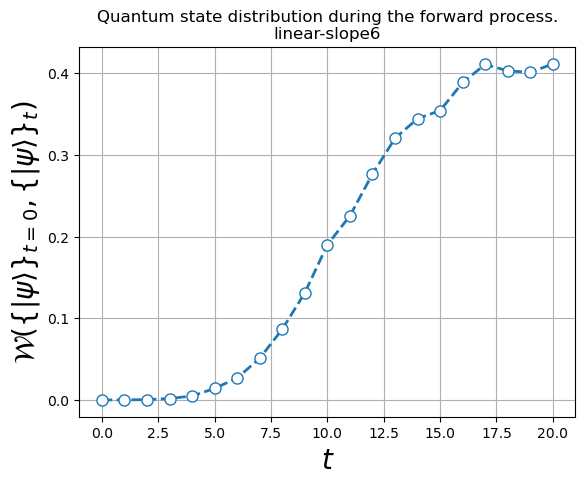

In [3]:
diffuser = QDDPMDiffuser(config, n_data, n_timesteps, n_features, device=device)
states_diffused =diffuser.diffuse()
wass = diffuser.compute_wassdist_forward()

fig, ax1 = plt.subplots()
ax1.plot(wass, 'o--', mfc='white', markersize=8, lw=2)
# plt.plot(wass)
ax1.set_ylabel(r'$\mathcal{W}\left(\{|\psi\rangle\}_{t=0}, \{|\psi\rangle\}_{t} \right)$', fontsize=20)
ax1.set_xlabel(r'$t$', fontsize=20)
# plt.xticks(range(n_timesteps+1))
ax1.grid(True)
ax1.set_title(f'Quantum state distribution during the forward process.\n{diffusion_schedule_nickname}')

# ax2 = ax1.twinx()
# ax2.plot(diffusion_weights.cpu(), c='orange', label='Diffusion weight')

100%|██████████| 21/21 [00:07<00:00,  2.89it/s]


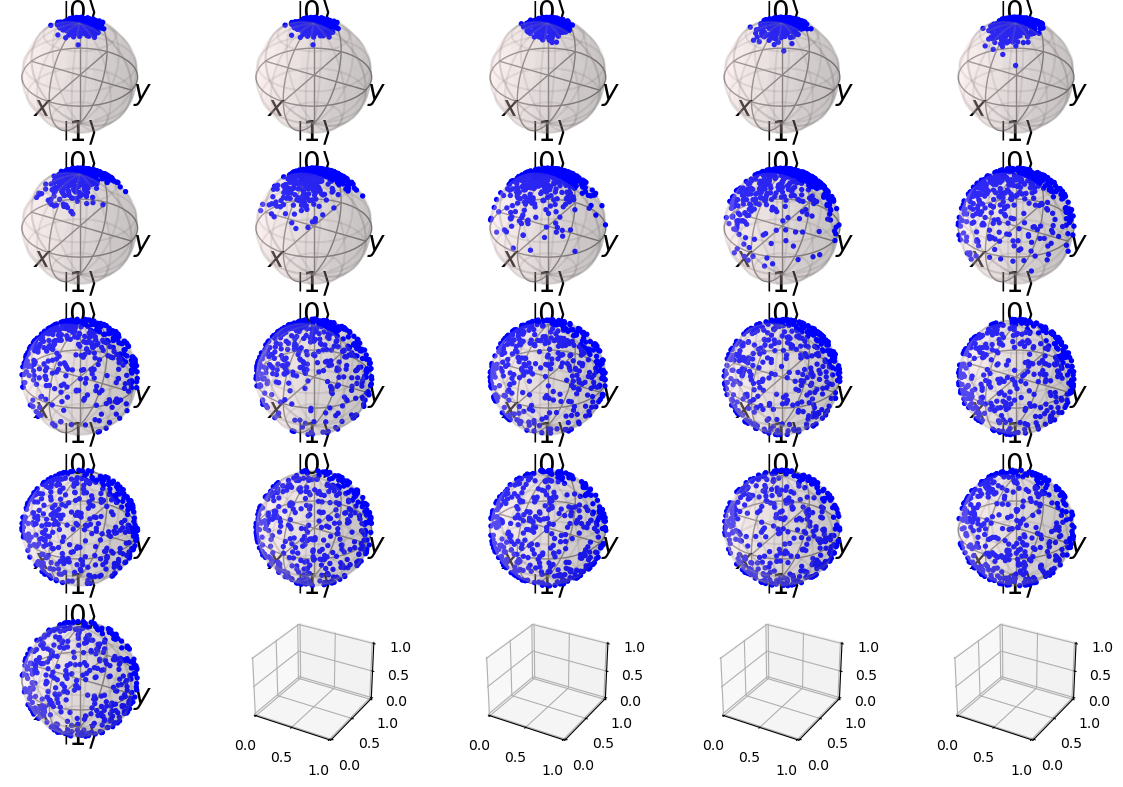

In [4]:
# Bloch visualize on the forward noise process
from opt_einsum import contract
import qutip as qt
from qutip import Bloch

def bloch_xyz(inputs):
    # obtain bloch sphere representation vector
    rho = contract('mi,mj->mij', inputs, inputs.conj())
    sigmas = [qt.sigmax().full(), qt.sigmay().full(), qt.sigmaz().full()]
    pos = [np.real(contract('mii->m', contract('mij,jk->mik', rho, x))) for x in sigmas]
    return pos

cols = 5
fig, axs = plt.subplots(n_timesteps//cols+1, cols, figsize=(12, 8), subplot_kw={'projection': '3d'})
for i in tqdm(range(n_timesteps+1)):
    states = states_diffused[i].numpy()
    xs0, ys0, zs0 = bloch_xyz(states)
    b0 = Bloch(fig=fig, axes=axs[i//cols, i%cols])
    b0.clear()
    b0.add_points([xs0, ys0, zs0])
    b0.point_color = ['b']*n_data
    b0.point_style = 'm'
    b0.point_size = 8*np.ones(n_data)
    b0.render()
plt.tight_layout()

Train a simple MLP to denoise one single (arbitrary) timestep

In [ ]:
class MLP(torch.nn.Module):
    def __init__(self, input_feats, n_hidden_layers, output_feats):
        super().__init__()
        input_dim = 2*input_feats
        output_dim = 2*output_feats
        hidden_dim = 8*input_dim
        layers = []
        for _ in range(n_hidden_layers):
            layers.append(torch.nn.Linear(input_dim, hidden_dim))
            layers.append(torch.nn.ReLU())
            input_dim = hidden_dim
        layers.append(torch.nn.Linear(input_dim, output_dim))
        self.mlp = torch.nn.Sequential(*layers)

    def forward(self, x): # x.shape = (batch_size, n_features (complex))
        batch_size = x.shape[0]
        x = torch.view_as_real(x) # (batch_size, n_features, 2)
        x = x.view(batch_size, -1)
        x_output = self.mlp(x)
        x_output = x_output.view(batch_size, -1, 2)
        x_output = torch.view_as_complex(x_output)
        norm = torch.linalg.norm(x_output, dim=1, keepdim=True)
        x_output = x_output / norm
        return x_output
    
def quantum_mean_infidelity(pred, true):
    # pred and true are [n_data, n_features] complex tensors
    inner_product = torch.linalg.vecdot(true, pred, dim=-1) # [n_data]
    fidelity = inner_product.abs().pow(2)
    infidelity = 1 - fidelity
    return infidelity.mean()

def eval(model, x):
    model.eval()
    y = model(x)
    return y

In [ ]:
device = torch.device('cpu')
input_feats = 2**n_qubits
output_feats = input_feats
n_hidden_layers = 3
model = MLP(input_feats, n_hidden_layers, output_feats).to(device)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(trainable_params)
print(model)

2404
MLP(
  (mlp): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=4, bias=True)
  )
)


In [ ]:
device = torch.device('cpu')
input_feats = 2**n_qubits
output_feats = input_feats
n_hidden_layers = 3
model = MLP(input_feats, n_hidden_layers, output_feats).to(device)
loss_fn = quantum_mean_infidelity
lr = 1e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
# optimizer = pytorch_optimizer.SOAP(model.parameters(), lr=lr)
# lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=1000, eta_min=lr*0.001)
n_epochs = 10000
pbar = tqdm(range(n_epochs))
batch_size = 100

# Select a timestep
TIMESTEP = n_timesteps # 20 --> 19
X, y = states_diffused[TIMESTEP], states_diffused[TIMESTEP-1]
ts = torch.ones_like(X) * TIMESTEP
train_dataloader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X, y, ts), batch_size=batch_size, shuffle=True)

loss_hist = []
best_loss = float('inf')
last_save_epoch = 0
model.train()
for epoch in pbar:
    loss_epoch = 0
    for batch in train_dataloader:
        X, y, ts = batch
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        x = model(X)
        loss = loss_fn(x, y)
        loss.backward()
        optimizer.step()
        loss_value = loss.item()
        loss_epoch += loss_value
    # lr_scheduler.step()
    avg_loss_epoch = loss_epoch / len(train_dataloader)
    loss_hist.append(avg_loss_epoch)
    pbar.set_description(f'Epoch {epoch+1}/{n_epochs} Loss: {loss_value:.3e}, Last_save: {last_save_epoch}')

    if avg_loss_epoch < best_loss:
        best_loss = avg_loss_epoch
        last_save_epoch = epoch
        dir , filename = Path('results_simple_mlp'), 'bestmodel_pretrained.pt'
        path = dir/filename
        dir.mkdir(parents=True, exist_ok=True)
        torch.save(model.state_dict(), path)

Epoch 10000/10000 Loss: 5.869e-02: 100%|██████████| 10000/10000 [00:57<00:00, 173.96it/s]


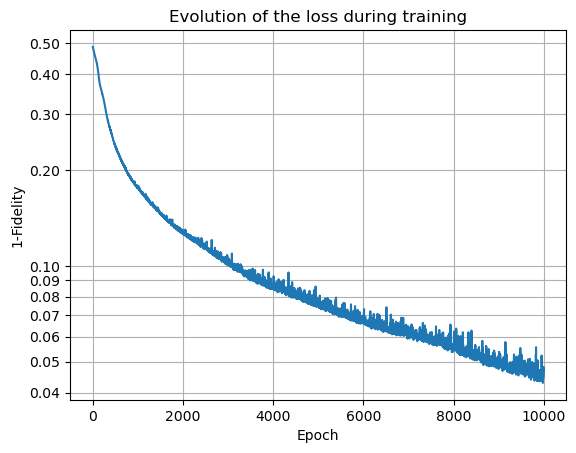

Wass distance: 0.024 --> 0.022
Difference: 0.002
Total Trainable Parameters: 2,404


In [17]:
# Plot the evolution of the loss
import matplotlib.ticker as ticker
fig, ax = plt.subplots()
ax.plot(loss_hist)
ax.set_xlabel('Epoch')
ax.set_ylabel('1-Fidelity')
ax.set_yscale('log')
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=range(1, 10)))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax.grid(True)
ax.set_title('Evolution of the loss during training')
plt.show()

# Print the evolution of the wass distance
from src.QDDPM_torch_angel import WassDistance
x = eval(model, X)
wass_true = WassDistance(X, y)
wass_pred = WassDistance(X, x)
print(f'Wass distance: {wass_true:.3f} --> {wass_pred:.3f}')
print(f'Difference: {wass_true - wass_pred:.3f}')

# Print some stats of the model
n_params = sum(p.numel() for p in model.parameters())
print(f'Total Trainable Parameters: {n_params:,}')

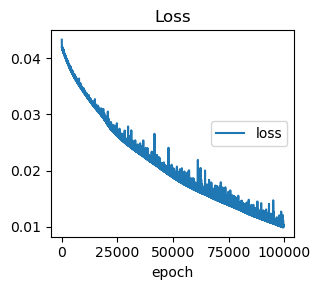

Epoch 99536/100000 Loss: 1.002e-02: 100%|█████████▉| 99528/100000 [09:17<00:03, 136.48it/s]

Loss
	loss             	 (min:    0.010, max:    0.043, cur:    0.010)


Epoch 100000/100000 Loss: 9.920e-03: 100%|██████████| 100000/100000 [09:20<00:00, 178.52it/s]


In [21]:
# Second round: fine-tuning with lower lr.
from livelossplot import PlotLosses
import copy
liveloss = PlotLosses(figsize=(6,3))
lr = 1e-5
n_epochs = 100000
pbar = tqdm(range(n_epochs))
path = Path('results_simple_mlp')/'bestmodel_pretrained.pt'
checkpoint = torch.load(path)
model_finetuned = MLP(input_feats, n_hidden_layers, output_feats).to(device)
model_finetuned.load_state_dict(checkpoint)
optimizer = torch.optim.AdamW(model_finetuned.parameters(), lr=lr)

logs = {}
best_loss = float('inf')
last_save_epoch = 0
model_finetuned.train()
for epoch in pbar:
    loss_epoch = 0
    for batch in train_dataloader:
        X, y, ts = batch
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        x = model_finetuned(X)
        loss = loss_fn(x, y)
        loss.backward()
        optimizer.step()
        loss_value = loss.item()
        loss_epoch += loss_value
    # lr_scheduler.step()
    avg_loss_epoch = loss_epoch / len(train_dataloader)
    logs['loss'] = avg_loss_epoch
    liveloss.update(logs)
    pbar.set_description(f'Epoch {epoch+1}/{n_epochs} Loss: {loss_value:.3e} Last_save: {last_save_epoch}')
    if avg_loss_epoch < best_loss:
        best_loss = avg_loss_epoch
        last_save_epoch = epoch
        dir , filename = Path('results_simple_mlp'), 'bestmodel_finetuned1.pt'
        path = dir/filename
        dir.mkdir(parents=True, exist_ok=True)
        torch.save(model.state_dict(), path)
    if epoch % 500 == 0:
        liveloss.send()

In [22]:
# Print the evolution of the wass distance
from src.QDDPM_torch_angel import WassDistance
x = eval(model_finetuned, X)
wass_true = WassDistance(X, y)
wass_pred = WassDistance(X, x)
print(f'Wass distance: {wass_true:.3f} --> {wass_pred:.3f}')
print(f'Difference: {wass_true - wass_pred:.3f}')

# Print some stats of the model
n_params = sum(p.numel() for p in model.parameters())
print(f'Total Trainable Parameters: {n_params:,}')

Wass distance: 0.029 --> 0.026
Difference: 0.003
Total Trainable Parameters: 2,404


# Bloch Visualize

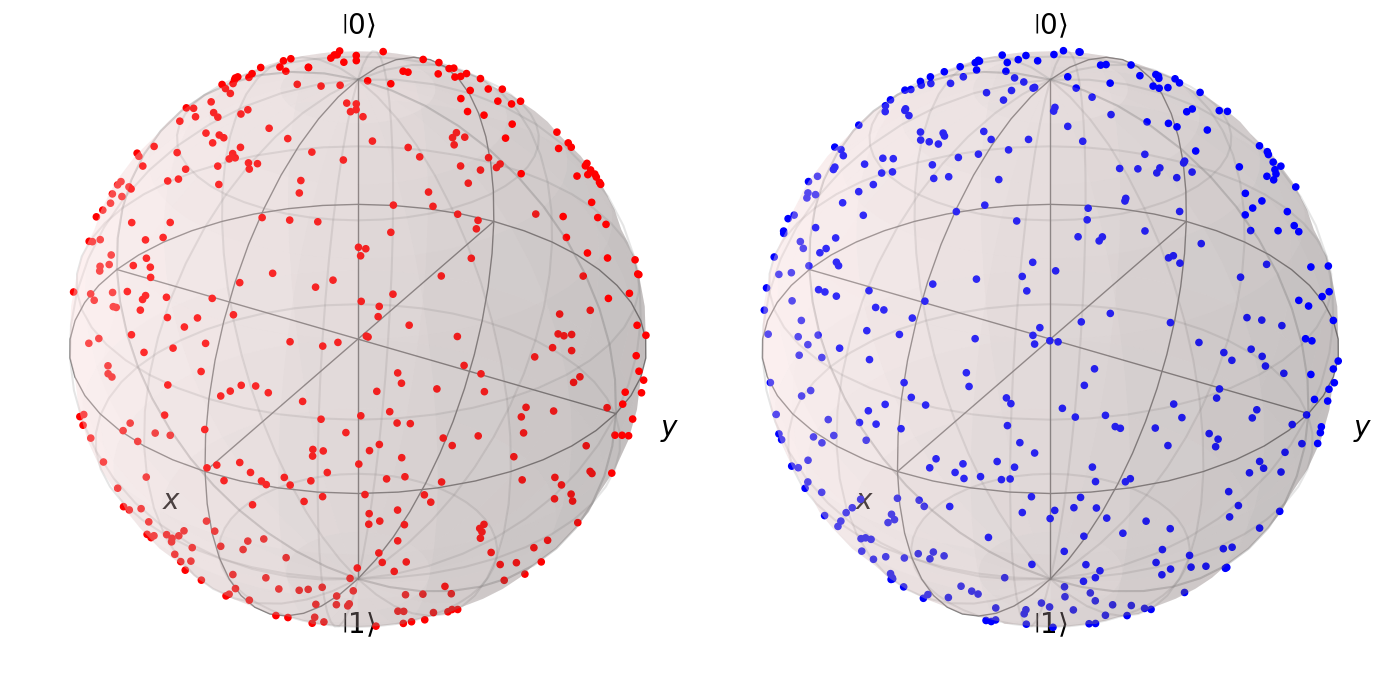

In [55]:
# Bloch visualize on the forward noise process
from opt_einsum import contract
import qutip as qt
from qutip import Bloch
TIMESTEP=20

def bloch_xyz(inputs):
    # obtain bloch sphere representation vector
    rho = contract('mi,mj->mij', inputs, inputs.conj())
    sigmas = [qt.sigmax().full(), qt.sigmay().full(), qt.sigmaz().full()]
    pos = [np.real(contract('mii->m', contract('mij,jk->mik', rho, x))) for x in sigmas]
    return pos

dir, filename = get_path_partial(type='diffusedqstates.npy')
diffused_states = np.load(dir / filename)

fig, axs = plt.subplots(1,2,figsize=(14,10), subplot_kw={'projection': '3d'})

b0 = Bloch(fig=fig, axes=axs[0])
y = diffused_states[TIMESTEP-1]
xs0, ys0, zs0 = bloch_xyz(y)
b0.clear()
b0.add_points([xs0, ys0, zs0])
b0.point_color = ['r']*n_data
b0.point_style = ['m']
b0.point_size = 20*np.ones(n_data)
b0.render()

X = torch.from_numpy(diffused_states[TIMESTEP])
x = eval(model_finetuned, X)
x = x.detach().cpu().numpy()
b0 = Bloch(fig=fig, axes=axs[1])
xs0, ys0, zs0 = bloch_xyz(x)
b0.clear()
b0.add_points([xs0, ys0, zs0])
b0.point_color = ['b']*n_data
b0.point_style = ['m']
b0.point_size = 20*np.ones(n_data)

b0.render()
plt.tight_layout()

/tmp/ipykernel_2310658/613046798.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path)


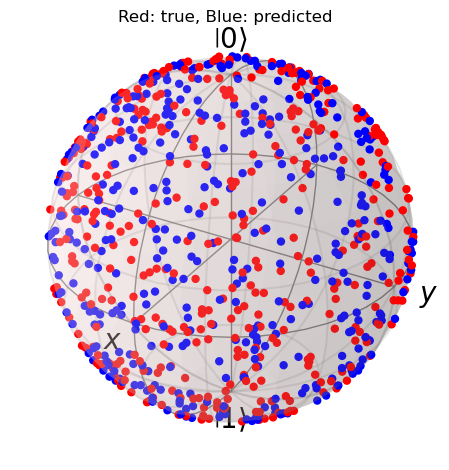

In [36]:
import qutip as qt
from qutip import Bloch
TIMESTEP = n_timesteps

path = Path('results_simple_mlp')/'bestmodel_finetuned1.pt'
checkpoint = torch.load(path)
model_finetuned = MLP(input_feats, n_hidden_layers, output_feats).to(device)
model_finetuned.load_state_dict(checkpoint)

fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
b = Bloch(fig=fig, axes=ax)

y = states_diffused[TIMESTEP-1].numpy()
red_points = bloch_xyz(y) # True

X = states_diffused[TIMESTEP]
x = eval(model_finetuned, X)
x = x.detach().cpu().numpy()
blue_points = bloch_xyz(x)

all_points = [np.concatenate((red_points[i], blue_points[i])) for i in range(3)]
b.add_points(all_points)
b.point_color = ['r']*red_points[0].shape[0] + ['b']*blue_points[0].shape[0]
b.point_style = 'm'

b.render()
ax.set_title(f'Red: true, Blue: predicted')
plt.tight_layout()

# Full chain

Hemos visto que este modelo, para un solo timesep, parece que funciona. El siguiente paso es entrenar uno para cada timestep.

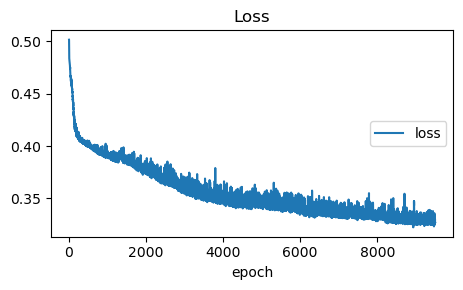

Loss
	loss             	 (min:    0.323, max:    0.501, cur:    0.327)


In [63]:
device = torch.device('cpu')
input_feats = 2**n_qubits
output_feats = input_feats
n_hidden_layers = 3
model = MLP(input_feats, n_hidden_layers, output_feats).to(device)
loss_fn = quantum_mean_infidelity
lr = 1e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
# optimizer = pytorch_optimizer.SOAP(model.parameters(), lr=lr)
# lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=1000, eta_min=lr*0.001)
n_epochs = 10000
pbar = tqdm(range(n_epochs))
batch_size = 100

# Select a timestep
for t in range(n_timesteps, -1, -1):
    liveloss = PlotLosses(figsize=(9,3))
    X, y = states_diffused[t], states_diffused[t-1]
    ts = torch.ones_like(X) * t
    train_dataloader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X, y, ts), batch_size=batch_size, shuffle=True)

    loss_hist = []
    best_loss = float('inf')
    last_save_epoch = 0
    model.train()
    for epoch in pbar:
        loss_epoch = 0
        for batch in train_dataloader:
            X, y, ts = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            x = model(X)
            loss = loss_fn(x, y)
            loss.backward()
            optimizer.step()
            loss_value = loss.item()
            loss_epoch += loss_value
        # lr_scheduler.step()
        avg_loss_epoch = loss_epoch / len(train_dataloader)
        loss_hist.append(avg_loss_epoch)
        logs['loss'] = avg_loss_epoch
        liveloss.update(logs)
        pbar.set_description(f'Epoch {epoch+1}/{n_epochs} Loss: {loss_value:.3e}, Last_save: {last_save_epoch}')

        if avg_loss_epoch < best_loss:
            best_loss = avg_loss_epoch
            last_save_epoch = epoch
            dir , filename = Path('results_simple_mlp'), f'bestmodel_pretrained_{t}.pt'
            path = dir/filename
            dir.mkdir(parents=True, exist_ok=True)
            torch.save({
                'model_state_dict': model.state_dict(),
                'loss_hist': loss_hist,
                }, path)
        if epoch % 500 == 0:
            liveloss.send()

In [ ]:
# Fine tuning
device = torch.device('cpu')
input_feats = 2**n_qubits
output_feats = input_feats
n_hidden_layers = 3
model = MLP(input_feats, n_hidden_layers, output_feats).to(device)
loss_fn = quantum_mean_infidelity
lr = 1e-5
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
# optimizer = pytorch_optimizer.SOAP(model.parameters(), lr=lr)
# lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=1000, eta_min=lr*0.001)
n_epochs = 10000
pbar = tqdm(range(n_epochs))
batch_size = 100

# Select a timestep
for t in range(n_timesteps, -1, -1):
    liveloss = PlotLosses(figsize=(9,3))
    X, y = states_diffused[t], states_diffused[t-1]
    ts = torch.ones_like(X) * t
    train_dataloader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X, y, ts), batch_size=batch_size, shuffle=True)

    path = Path('results_simple_mlp') / f'bestmodel_pretrained_{t}.pt'
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    loss_hist = []
    best_loss = float('inf')
    last_save_epoch = 0
    model.train()
    for epoch in pbar:
        loss_epoch = 0
        for batch in train_dataloader:
            X, y, ts = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            x = model(X)
            loss = loss_fn(x, y)
            loss.backward()
            optimizer.step()
            loss_value = loss.item()
            loss_epoch += loss_value
        # lr_scheduler.step()
        avg_loss_epoch = loss_epoch / len(train_dataloader)
        loss_hist.append(avg_loss_epoch)
        logs['loss'] = avg_loss_epoch
        liveloss.update(logs)
        pbar.set_description(f'Epoch {epoch+1}/{n_epochs} Loss: {loss_value:.3e}, Last_save: {last_save_epoch}')

        if avg_loss_epoch < best_loss:
            best_loss = avg_loss_epoch
            last_save_epoch = epoch
            dir , filename = Path('results_simple_mlp'), f'bestmodel_pretrained_{t}.pt'
            path = dir/filename
            dir.mkdir(parents=True, exist_ok=True)
            torch.save({
                'model_state_dict': model.state_dict(),
                'loss_hist': loss_hist,
                }, path)
        if epoch % 500 == 0:
            liveloss.send()

In [91]:
# Tratamos de optimizar algunos timesteps en concreto.
TIMESTEP = 20
path = Path('results_simple_mlp')/f'bestmodel_pretrained_{TIMESTEP}.pt'
checkpoint = torch.load(path)
best_loss = checkpoint['loss_hist'][-1]
print(f"{best_loss:.3e}")

3.134e-02


/tmp/ipykernel_2162270/2442338461.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path)


/tmp/ipykernel_2162270/2882676134.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path)


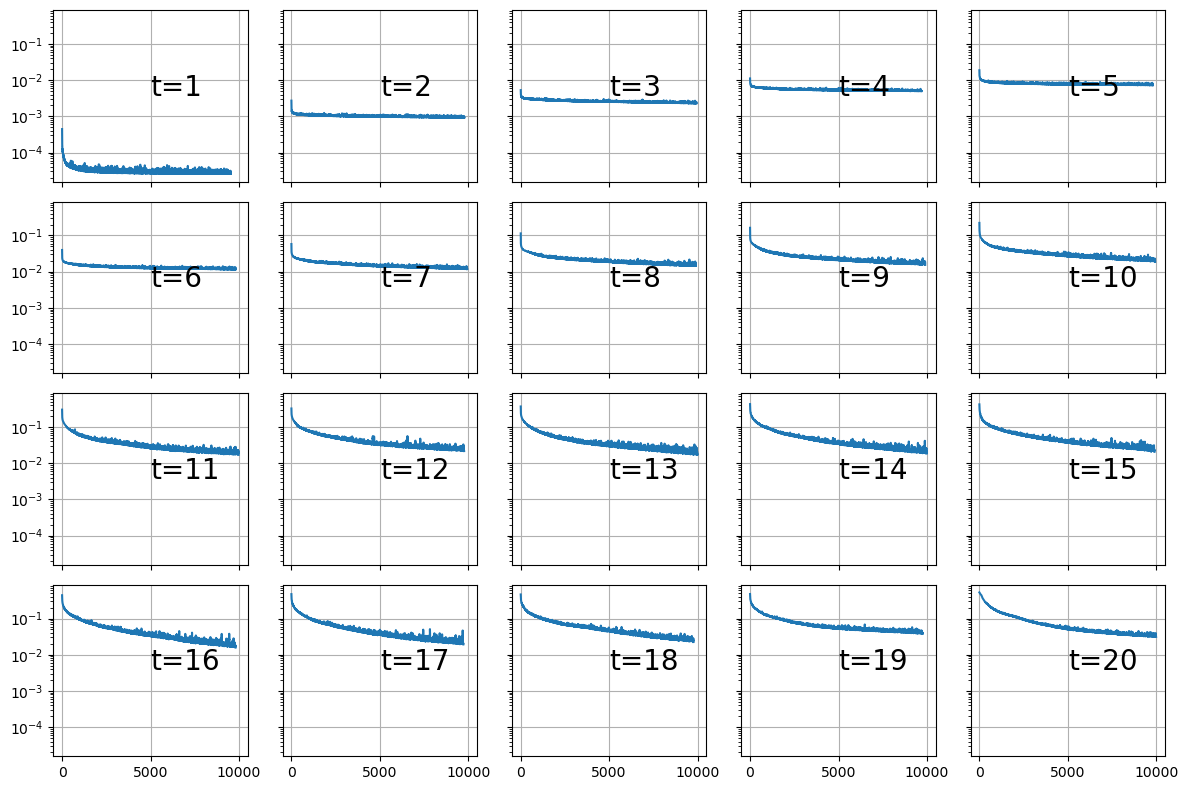

In [90]:
cols = 5
fig,axes = plt.subplots(n_timesteps//cols, cols, figsize=(12, 8), sharex=True, sharey=True)
for t in range(0, n_timesteps):
    path = Path('results_simple_mlp')/f'bestmodel_pretrained_{t+1}.pt'
    checkpoint = torch.load(path)
    loss_hist = checkpoint['loss_hist']
    ax = axes[t//cols, t%cols]
    ax.plot(loss_hist)
    ax.set_yscale('log')
    ax.text(0.5, 0.5, f't={t+1}', fontsize=20, transform=ax.transAxes)
    ax.grid(True)

fig.tight_layout()
    

Vale, hemos entrenado los modelos en su versión "perfecta", es decir, usando como input la snapshot del forward, y no la predicción del step t+1. Vamos a ver qué tal rinde así.

/tmp/ipykernel_2162270/2458574666.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path)
100%|██████████| 21/21 [00:06<00:00,  3.05it/s]


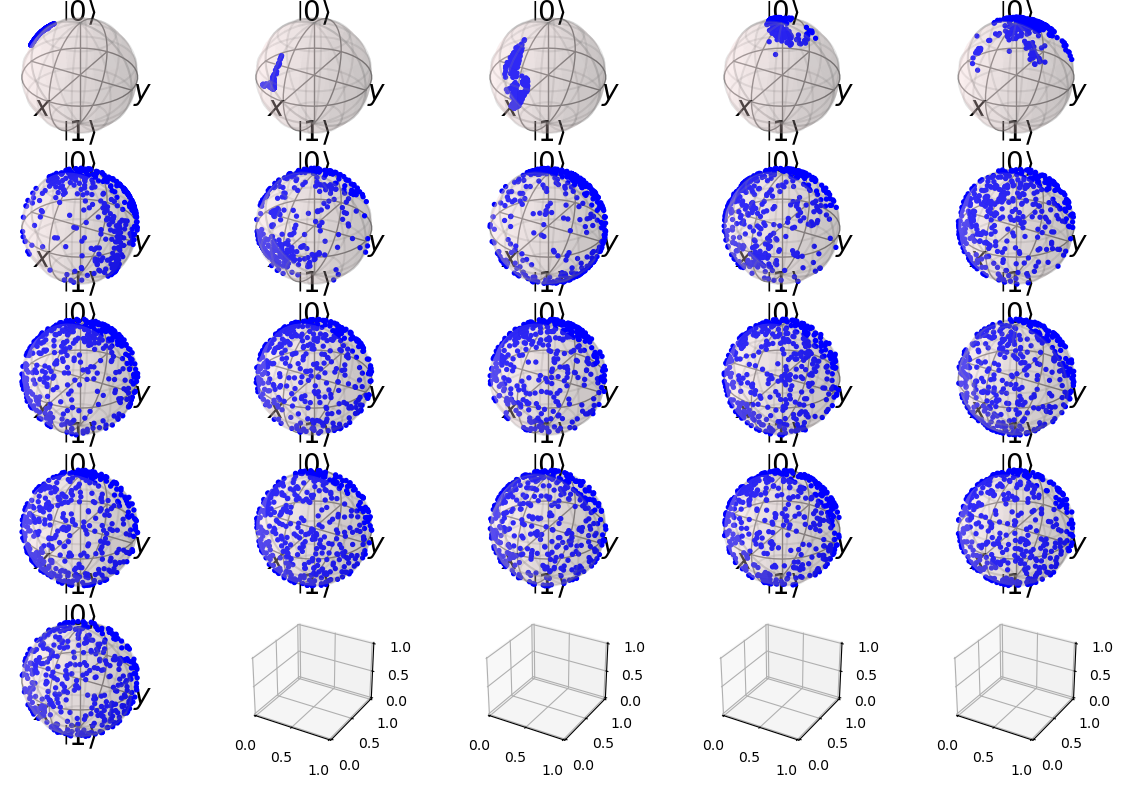

In [83]:
model = MLP(input_feats, n_hidden_layers, output_feats).to(device)

inputs_tplus1 = states_diffused[-1]
outputs = np.zeros((n_timesteps+1, n_data, 2**(n_qubits)), dtype=np.complex64)
outputs[n_timesteps] = inputs_tplus1.detach().cpu().numpy()
for t in range(n_timesteps, 0, -1):
    path = Path('results_simple_mlp')/f'bestmodel_pretrained_{t}.pt'
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict']) 
    inputs_tplus1 = eval(model, inputs_tplus1)
    outputs[t-1] = inputs_tplus1.detach().cpu().numpy()

# Bloch visualize on the forward noise process
from opt_einsum import contract
import qutip as qt
from qutip import Bloch

def bloch_xyz(inputs):
    # obtain bloch sphere representation vector
    rho = contract('mi,mj->mij', inputs, inputs.conj())
    sigmas = [qt.sigmax().full(), qt.sigmay().full(), qt.sigmaz().full()]
    pos = [np.real(contract('mii->m', contract('mij,jk->mik', rho, x))) for x in sigmas]
    return pos

cols = 5
fig, axs = plt.subplots(n_timesteps//cols+1, cols, figsize=(12, 8), subplot_kw={'projection': '3d'})
for i in tqdm(range(n_timesteps+1)):
    xs0, ys0, zs0 = bloch_xyz(outputs[i])
    b0 = Bloch(fig=fig, axes=axs[i//cols, i%cols])
    b0.clear()
    b0.add_points([xs0, ys0, zs0])
    b0.point_color = ['b']*n_data
    b0.point_style = 'm'
    b0.point_size = 8*np.ones(n_data)
    b0.render()
plt.tight_layout()

Se me ha borrado el progreso, pero falta el codigo del fine tuned 1 despues del pretrained. Los resultaods si que estan.

Resultados tras el finetuning:

/tmp/ipykernel_2310658/3880556774.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path)
/tmp/ipykernel_2310658/3880556774.py:25: FutureWarning: Y

IndexError: index 4 is out of bounds for axis 0 with size 4

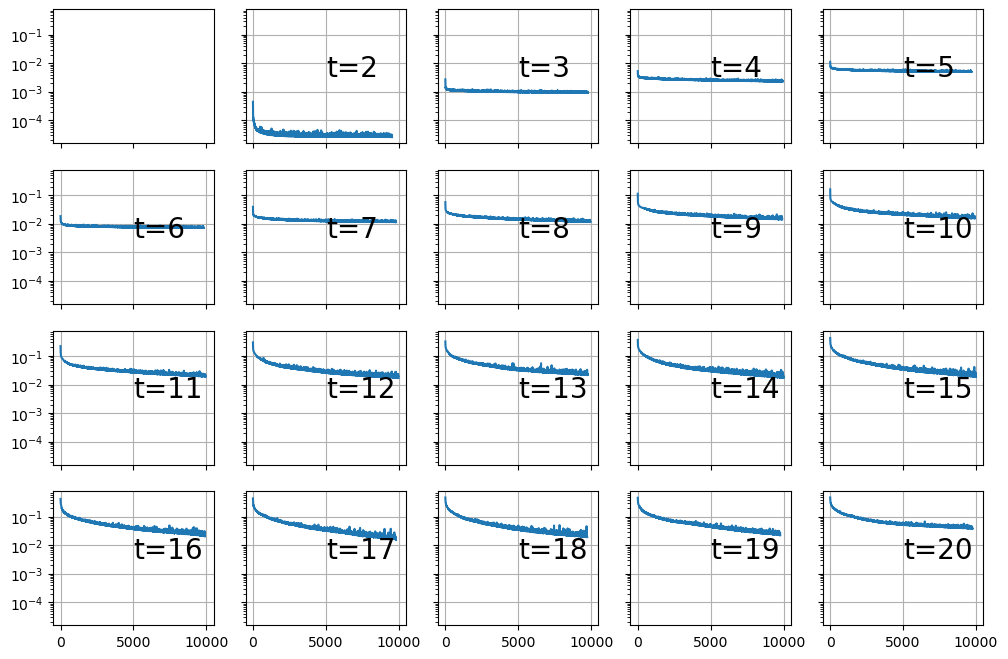

In [54]:
inputs_tplus1 = states_diffused[-1]
outputs = []
losses = []
for t in range(n_timesteps, 0, -1):
    path = Path('results_simple_mlp')/f'bestmodel_pretrained_{t}.pt'
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])

    inputs_tplus1 = eval(model, inputs_tplus1)
    outputs.append(inputs_tplus1.detach().cpu().numpy())

    losses.append(checkpoint['loss_hist'][-1])

# fig, axes = plt.subplots()
# axes.bar(range(n_timesteps, 0, -1), losses)
# axes.set_xticks(range(n_timesteps, 0, -1))
# axes.set_title("Lowest loss at each timestep")
# axes.set_ylabel("Loss")
# axes.set_xlabel("Timestep")

cols = 5
fig,axes = plt.subplots(n_timesteps//cols, cols, figsize=(12, 8), sharex=True, sharey=True)
for t in range(1, n_timesteps+1):
    path = Path('results_simple_mlp')/f'bestmodel_pretrained_{t}.pt'
    checkpoint = torch.load(path)
    loss_hist = checkpoint['loss_hist']
    ax = axes[t//cols, t%cols]
    ax.plot(loss_hist)
    ax.set_yscale('log')
    ax.text(0.5, 0.5, f't={t+1}', fontsize=20, transform=ax.transAxes)
    ax.grid(True)

fig.tight_layout()
    
None

 95%|█████████▌| 20/21 [00:07<00:00,  2.75it/s]


IndexError: list index out of range

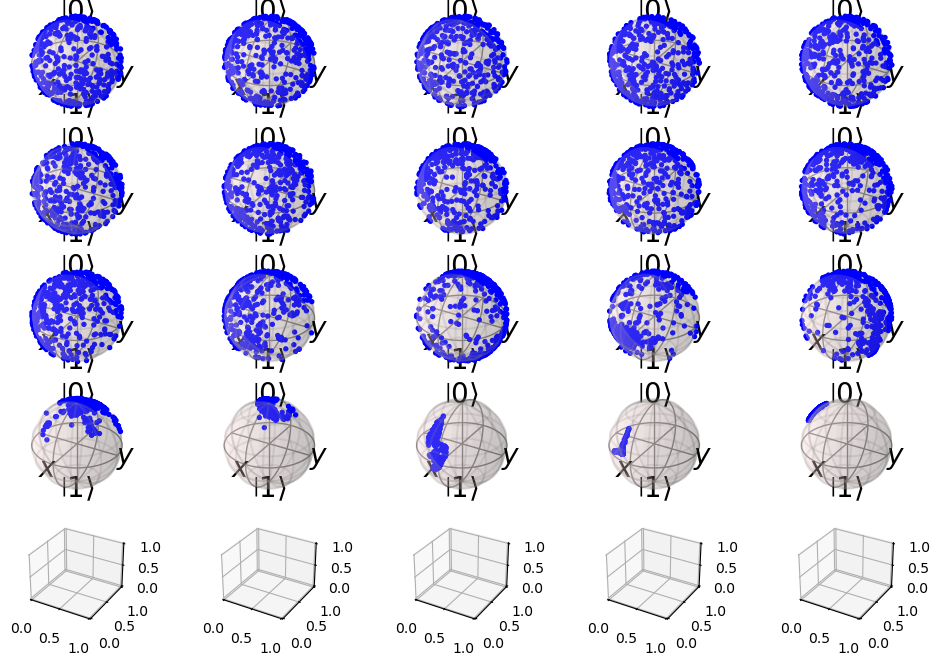

In [51]:
# Bloch visualize on the forward noise process
from opt_einsum import contract
import qutip as qt
from qutip import Bloch

def bloch_xyz(inputs):
    # obtain bloch sphere representation vector
    rho = contract('mi,mj->mij', inputs, inputs.conj())
    sigmas = [qt.sigmax().full(), qt.sigmay().full(), qt.sigmaz().full()]
    pos = [np.real(contract('mii->m', contract('mij,jk->mik', rho, x))) for x in sigmas]
    return pos

cols = 5
fig, axs = plt.subplots(n_timesteps//cols+1, cols, figsize=(12, 8), subplot_kw={'projection': '3d'})
for i in tqdm(range(n_timesteps+1)):
    xs0, ys0, zs0 = bloch_xyz(outputs[i])
    b0 = Bloch(fig=fig, axes=axs[i//cols, i%cols])
    b0.clear()
    b0.add_points([xs0, ys0, zs0])
    b0.point_color = ['b']*n_data
    b0.point_style = 'm'
    b0.point_size = 8*np.ones(n_data)
    b0.render()
plt.tight_layout()